In [1]:
import pandas as pd 
import numpy as np 

In [2]:
class Option:
    def __init__(self, strike: float, premium: float, expiry: str):
        self.strike = strike
        self.premium = premium
        self.expiry = expiry
        self.spot_price = None

    def insert_spot(self, spot_price: float):
        self.spot_price = spot_price
    
    def short_call(self):
        # Payoff for short call: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return self.premium - intrinsic_value
    
    def long_call(self):
        # Payoff for long call: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return intrinsic_value - self.premium
    
    def short_put(self):
        # Payoff for short put: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return self.premium - intrinsic_value
    
    def long_put(self):
        # Payoff for long put: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return intrinsic_value - self.premium


class IronCondor:
    def __init__(self, direction: str, strikes: dict, premiums: dict, expiry: str):
        """
        Initialize the Iron Condor strategy with strikes and premiums for the options.
        
        direction: long, (short) Iron Condor
        1. Short (Long) 1 OTM Put (strike 1)
        2. Long (Short) 1 close to ATM Put (strike 2)
        3. Long (Short) 1 close to ATM Call (strike 3)
        4. Short (Long) 1 OTM Call (strike 4)        

        strikes: a dictionary of strikes for the 4 options (strike1 to strike4)
        premiums: a dictionary of premiums for the 4 options (premium1 to premium4)
        expiry: expiration date of the options
        """
        self.premiums = premiums
        self.direction = direction
        self.short_put_option = Option(strikes['strike1'], premiums['premium1'], expiry)
        self.long_put_option = Option(strikes['strike2'], premiums['premium2'], expiry)
        self.long_call_option = Option(strikes['strike3'], premiums['premium3'], expiry)
        self.short_call_option = Option(strikes['strike4'], premiums['premium4'], expiry)

    def initial_cashflow(self):
        """
        Calculate the initial cashflow of the Iron Condor strategy.
        """
        if self.direction == "long":
            initial_cashflow = self.premiums['premium1'] - self.premiums['premium2'] - self.premiums['premium3'] + self.premiums['premium4']
        elif self.direction == "short":
            initial_cashflow = -self.premiums['premium1'] + self.premiums['premium2'] + self.premiums['premium3'] - self.premiums['premium4']
        
        return initial_cashflow

    def insert_spot(self, spot_price: float):
        """
        Insert the current spot price for all the options in the Iron Condor strategy.
        """
        self.short_put_option.insert_spot(spot_price)
        self.long_put_option.insert_spot(spot_price)
        self.long_call_option.insert_spot(spot_price)
        self.short_call_option.insert_spot(spot_price)
    
    def payoff(self):
        """
        Calculate the total payoff (profit or loss) of the Iron Condor strategy.
        
        direction: 'long' for long Iron Condor, 'short' for short Iron Condor
        """
        if self.direction == "long":
            short_put = self.short_put_option.short_put()
            long_put = self.long_put_option.long_put()
            long_call = self.long_call_option.long_call()
            short_call = self.short_call_option.short_call()
            total_payoff = short_put + long_put + long_call + short_call
        elif self.direction == "short":
            long_put = -self.long_put_option.long_put()
            short_put = -self.short_put_option.short_put()
            short_call = -self.short_call_option.short_call()
            long_call = -self.long_call_option.long_call()
            total_payoff = long_put + short_put + short_call + long_call
        
        return float(total_payoff)

class OptionsBacktester:
    def __init__(self,
                 signal_df: pd.DataFrame,
                 spot_price_df: pd.DataFrame,
                 options_df: pd.DataFrame,
                 upper_threshold: float,
                 lower_threshold: float,
                 option_type: str,
                 dynamic_option_strategy: bool = False,
                 dynamic_strike: bool = False):
        
        print("Initializing OptionsBacktester")
        print("Signal DataFrame shape:", signal_df.shape)
        print("Spot Price DataFrame shape:", spot_price_df.shape)
        print("Options DataFrame shape:", options_df.shape)

        self.signal_df = signal_df.copy()  # Keep all columns
        self.spot_price_df = spot_price_df.copy()
        self.options_df = options_df.copy()
        self.upper_threshold = upper_threshold
        self.lower_threshold = lower_threshold
        self.option_type = option_type
        self.dynamic_option_strategy = dynamic_option_strategy
        self.dynamic_strike = dynamic_strike

        # Shift the DataFrames
        shifted_spot_price_df = self.spot_price_df.shift()
        shifted_options_df = self.options_df.shift()

        # Debug prints for shifted DataFrames
        print("Shifted Spot Price DataFrame shape:", shifted_spot_price_df.shape)
        print("Shifted Options DataFrame shape:", shifted_options_df.shape)

        # Concatenate DataFrames
        self.comb_df = pd.concat([self.signal_df, shifted_spot_price_df, shifted_options_df], axis=1)

        # Debug print for combined DataFrame shape
        print("Combined DataFrame shape after concat:", self.comb_df.shape)

        # Ensure to drop any rows with NaN values that may have resulted from shifts
        self.comb_df.dropna(inplace=True)

        # Define action based on thresholds
        if "signal" in self.comb_df.columns:  # Ensure "signal" column exists
            self.comb_df["action"] = np.where(
                self.comb_df["signal"] > self.upper_threshold, 1,
                np.where(self.comb_df["signal"] < self.lower_threshold, -1, 0)
            )
        else:
            raise ValueError("Expected 'signal' column not found in combined DataFrame.")

    def long_short_vol_df(self):
        self.trading_df = {}
        for index, row in self.comb_df.iterrows():
            if row["action"] != 0:
                self.trading_df[index] = self.comb_df.loc[index]

In [80]:
day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
xlu_options = xlu_options.set_index("date")
xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.min()")).reset_index(level=0, drop=True)
xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)
xlu_filtered_options["days to expiry"] = (xlu_filtered_options["exdate"] - xlu_filtered_options.index).dt.days
xlu_filtered_options

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,day,ex_day,days to expiry
date,,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,31.0,0.0000,0.1250,0.0,0.423886,0.068868,0.062562,-4.271427,0.662345,0.0,Monday,Saturday,12
2000-01-10,XLU,2000-01-22,P,29.0,1.4375,1.6250,0.0,0.271660,-0.839551,0.179317,-4.941929,1.211415,0.0,Monday,Saturday,12
2000-01-10,XLU,2000-01-22,P,30.0,2.3750,2.6250,0.0,0.353248,-0.899561,0.099878,-4.593377,0.872273,0.0,Monday,Saturday,12
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,Monday,Saturday,12
2000-01-10,XLU,2000-01-22,C,27.0,0.5625,0.7500,0.0,0.140491,0.799844,0.397932,-2.952004,1.393989,0.0,Monday,Saturday,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,XLU,2023-09-01,P,60.5,0.0000,0.0200,17.0,0.379238,-0.021437,0.041134,-11.656990,0.169143,0.0,Thursday,Friday,1
2023-08-31,XLU,2023-09-01,P,61.0,0.0000,0.0200,103.0,0.312279,-0.025489,0.057789,-11.088450,0.195682,5.0,Thursday,Friday,1
2023-08-31,XLU,2023-09-01,P,61.5,0.0000,0.0200,100.0,0.243774,-0.031731,0.088816,-10.360040,0.235267,1.0,Thursday,Friday,1


In [4]:
xlu_pred = pd.read_csv("data/xlu_pred.csv", parse_dates=True, index_col=0).rename(columns={"0": "Rolling Pred"})
xlu_iv = pd.read_csv("data/XLU_IV.csv", parse_dates=True, index_col=0)
xlu_vrp = (xlu_iv["Average IV"] - xlu_pred["Rolling Pred"]).dropna()

<Axes: >

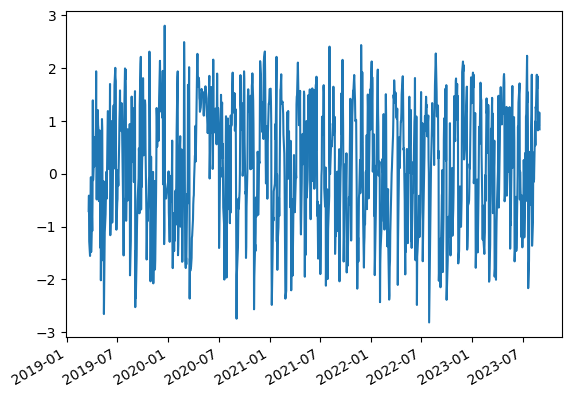

In [5]:
from data_wrangling import rolling_z_score
xlu_vrp_standardised = rolling_z_score(xlu_vrp, window=10)
xlu_vrp_standardised.plot()

In [108]:
upper_threshold = 1.5060942406259028
lower_threshold = -1.527742191923204

xlu_filtered_options["vrp"] = xlu_vrp_standardised
xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
xlu_time_series["day"] = xlu_time_series.index.weekday
xlu_time_series["vrp"] = xlu_vrp_standardised
xlu_time_series["signal"] = np.where(xlu_time_series["vrp"] > upper_threshold, 1, np.where(xlu_time_series["vrp"] < lower_threshold, -1, 0))
xlu_time_series["action"] = np.where((xlu_time_series["signal"] == 1)  & (xlu_time_series.index.weekday != 4), 1, 
                                     np.where((xlu_time_series["signal"] == -1) & (xlu_time_series.index.weekday != 4), -1, 
                                              0))
xlu_time_series.dropna(inplace=True)
xlu_time_series

def ensure_weekly_action(df):
    last_action = 0
    last_week = -1

    for i in range(len(df)):
        current_week = df.index[i].isocalendar()[1]  # Get the week number
        current_day = df["day"].iloc[i]

        if current_week != last_week:  # Reset at the start of a new week
            last_action = 0
            last_week = current_week

        if last_action != 0 and df["action"].iloc[i] != 0:
            # If an action has already occurred this week, set to 0
            df.at[df.index[i], "action"] = 0
        elif df["action"].iloc[i] != 0:
            # If this is the first action of the week, update last_action
            last_action = df["action"].iloc[i]

    return df

xlu_time_series = ensure_weekly_action(xlu_time_series)
xlu_time_series["action"] = xlu_time_series["action"].shift()
xlu_time_series["days to expiry"] = xlu_filtered_options["days to expiry"].iloc[:len(xlu_time_series)].values
xlu_time_series["volatility"] = xlu_iv["Average IV"].iloc[:len(xlu_time_series)].values
xlu_time_series

,Open,High,Low,Close,Adj Close,Volume,day,vrp,signal,action,days to expiry,volatility
Date,,,,,,,,,,,,
2019-03-20,57.419998,57.919998,57.169998,57.459999,48.255390,18880500,2,-0.707107,0,NaN,12,0.165813
2019-03-21,57.500000,58.189999,57.410000,58.070000,48.767689,15371800,3,-0.413402,0,0.0,12,0.149687
2019-03-22,58.290001,58.900002,58.070000,58.490002,49.120403,20452500,4,-1.278116,0,0.0,12,0.156742
2019-03-25,58.540001,58.720001,58.299999,58.540001,49.162395,13763000,0,-1.555630,-1,0.0,12,0.137006
2019-03-26,58.570000,59.000000,58.490002,58.959999,49.515114,15699700,1,-1.118795,0,-1.0,12,0.156174
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-25,63.240002,63.950001,63.200001,63.630001,61.106991,12490500,4,0.823560,0,0.0,9,0.205071
2023-08-28,63.740002,64.089996,63.490002,63.619999,61.097385,8663200,0,1.091036,0,0.0,9,0.180537
2023-08-29,63.700001,64.050003,63.439999,63.860001,61.327869,11873100,1,0.908154,0,0.0,9,0.175733


In [109]:
xlu_filtered_options.dropna(subset=["strike_price", "best_bid", "best_offer", "cp_flag"], inplace=True)

## original backtester

In [110]:
def myround(x, base=5):
    return base * round(x/base)

ironcondor_tracker = {}

for index, row in xlu_time_series.iterrows():
    if row["action"] == 1:
        spot_open = row["Open"]

        strikes = {
        "strike1": myround(spot_open * 0.9681247806559973, base=5),
        "strike2": myround(spot_open * 1.0137616507710108, base=5),
        "strike3": myround(spot_open * 1.0152435715790415, base=5),
        "strike4": myround(spot_open * 1.05, base=5)
    }
        
        if row["action"] == 1:
            direction = "long"
            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }
        
        expiry = xlu_filtered_options.loc[index]["exdate"].min()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, expiry)
    
    elif row["action"] == 0:
        ironcondor_tracker[index] = (None, None)

## new backtester draft (update doesnt work)

In [96]:
def myround(x, base=5):
    return base * round(x / base)

ironcondor_tracker = {}

for index, row in xlu_time_series.iterrows():
    if row["action"] == 1:
        spot_open = row["Open"]

        # Calculate projected volatility range
        days_to_expiration = row["days to expiry"]  # Set according to your time frame (e.g., weekly options)
        daily_volatility = row["volatility"]  
        projected_move = spot_open * daily_volatility * np.sqrt(days_to_expiration / 252)

        # Dynamic strikes based on projected move
        strikes = {
            "strike1": myround(spot_open - projected_move, base=5),
            "strike2": myround(spot_open - projected_move / 2, base=5),
            "strike3": myround(spot_open + projected_move / 2, base=5),
            "strike4": myround(spot_open + projected_move, base=5)
        }

        # Define direction and premiums
        direction = "long"
        premiums = {
            "premium1": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
            ],
            "premium2": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
            ],
            "premium3": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
            ],
            "premium4": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
            ]
        }

        expiry = xlu_filtered_options.loc[index]["exdate"].min()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, expiry)

    elif row["action"] == 0:
        ironcondor_tracker[index] = (None, None)

In [111]:
ironcondor_tracker

{Timestamp('2019-03-21 00:00:00'): (None, None),
 Timestamp('2019-03-22 00:00:00'): (None, None),
 Timestamp('2019-03-25 00:00:00'): (None, None),
 Timestamp('2019-03-27 00:00:00'): (None, None),
 Timestamp('2019-03-28 00:00:00'): (None, None),
 Timestamp('2019-03-29 00:00:00'): (None, None),
 Timestamp('2019-04-01 00:00:00'): (None, None),
 Timestamp('2019-04-02 00:00:00'): (None, None),
 Timestamp('2019-04-03 00:00:00'): (None, None),
 Timestamp('2019-04-04 00:00:00'): (None, None),
 Timestamp('2019-04-05 00:00:00'): (None, None),
 Timestamp('2019-04-08 00:00:00'): (None, None),
 Timestamp('2019-04-09 00:00:00'): (None, None),
 Timestamp('2019-04-10 00:00:00'): (None, None),
 Timestamp('2019-04-11 00:00:00'): (None, None),
 Timestamp('2019-04-12 00:00:00'): (None, None),
 Timestamp('2019-04-15 00:00:00'): (None, None),
 Timestamp('2019-04-16 00:00:00'): (None, None),
 Timestamp('2019-04-17 00:00:00'): (<__main__.IronCondor at 0x2e9875cfc70>,
  Timestamp('2019-04-18 00:00:00')),
 Time

In [112]:
pnl_dict = {}
for date, (ironcondor, expiry) in ironcondor_tracker.items():
    try:
        ironcondor.insert_spot(xlu_time_series.at[expiry, "Close"])
        pnl_dict[date] = ironcondor.payoff()
    except KeyError:
        continue
    except AttributeError:
        pnl_dict[date] = 0

C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)


<Axes: >

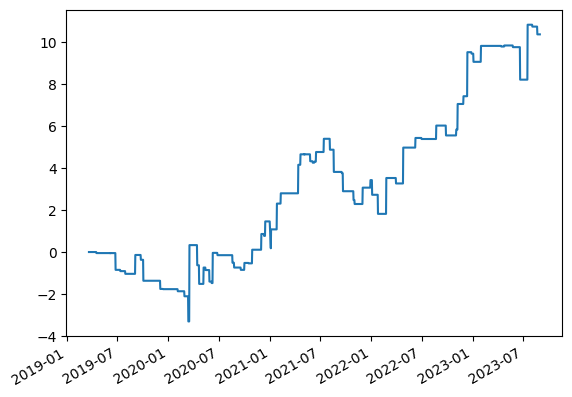

In [113]:
pd.Series(pnl_dict).cumsum().plot()

## optimise strike prices (not in use anymore)

In [77]:
# Get unique valid strikes for quick lookups
valid_strikes = set(xlu_filtered_options["strike_price"].unique())

def objective_function(params):
    # Unpack parameters
    strike_multiplier_1, strike_multiplier_2, strike_multiplier_3, strike_multiplier_4 = params

    pnl_dict = {}
    ironcondor_tracker = {}

    for index, row in xlu_time_series.iterrows():
        if row["action"] == 1:
            spot_open = row["Open"]

            # Calculate strikes based on current spot_open
            strikes = {
                "strike1": myround(spot_open * max(0.90, min(1.00, strike_multiplier_1)), base=5),
                "strike2": myround(spot_open * max(0.95, min(1.05, strike_multiplier_2)), base=5),
                "strike3": myround(spot_open * max(0.95, min(1.05, strike_multiplier_3)), base=5),
                "strike4": myround(spot_open * max(1.00, min(1.10, strike_multiplier_4)), base=5)
            }

            # Check if all strikes are valid
            if not all(strike in valid_strikes for strike in strikes.values()):
                return float('inf')  # Penalize for invalid strikes

            # Retrieve premiums, handling any potential empty lookups
            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ].iloc[0] if not xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P')
                ].empty else 0,
                
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ].iloc[0] if not xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P')
                ].empty else 0,
                
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ].iloc[0] if not xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C')
                ].empty else 0,
                
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ].iloc[0] if not xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C')
                ].empty else 0
            }

        
            expiry = xlu_filtered_options.loc[index]["exdate"].min()
            ironcondor = IronCondor(direction="long", strikes=strikes, premiums=premiums, expiry=expiry)
            ironcondor_tracker[index] = (ironcondor, expiry)
    
    for date, (ironcondor, expiry) in ironcondor_tracker.items():
        try:
            ironcondor.insert_spot(xlu_time_series.at[expiry, "Close"])
            pnl_dict[date] = ironcondor.payoff()
        except KeyError:
            continue
        except AttributeError:
            pnl_dict[date] = 0

    # Calculate total P&L
    total_pnl = np.sum(list(pnl_dict.values()))
    
    return -total_pnl  # We minimize the negative P&L

In [94]:
from skopt import gp_minimize

# Narrow search space
space_narrow = [
    (0.95, 1.00),  # Multiplier for strike 1
    (0.97, 1.03),  # Multiplier for strike 2
    (0.97, 1.03),  # Multiplier for strike 3
    (1.00, 1.05)   # Multiplier for strike 4
]

# Broad search space
space_broad = [
    (0.85, 1.05),
    (0.90, 1.10),
    (0.90, 1.10),
    (1.05, 1.15)
]

# Run Bayesian optimization on each space and compare results
result_narrow = gp_minimize(objective_function, space_narrow, n_calls=50, random_state=42)
result_broad = gp_minimize(objective_function, space_broad, n_calls=50, random_state=42)

print("Best parameters (narrow space):", result_narrow.x)
print("Best negative P&L (narrow space):", result_narrow.fun)

print("Best parameters (broad space):", result_broad.x)
print("Best negative P&L (broad space):", result_broad.fun)

Best parameters (narrow space): [0.9681247806559973, 1.0137616507710108, 1.0152435715790415, 1.05]
Best negative P&L (narrow space): -5.390011138916016
Best parameters (broad space): [0.85, 0.9996594319267713, 1.0240304502669768, 1.05]
Best negative P&L (broad space): -1.3700077819824215


## optimise thresholds (maximise sharpe ratio)

In [100]:
from skopt import gp_minimize
from skopt.space import Real

# Define the objective function for Bayesian Optimization
def objective(params, xlu_time_series):
    upper_threshold, lower_threshold = params

    # Copy xlu_time_series to avoid modifying the original data
    df = xlu_time_series.copy()

    # Update thresholds in the copied DataFrame
    df["signal"] = np.where(df["vrp"] > upper_threshold, 1, 
                            np.where(df["vrp"] < lower_threshold, -1, 0))
    df["action"] = np.where((df["signal"] == 1)  & (df.index.weekday != 4), 1, 
                            np.where((df["signal"] == -1) & (df.index.weekday != 4), -1, 0))

    # Ensure weekly action
    df = ensure_weekly_action(df)
    df["action"] = df["action"].shift()

    # Re-run iron condor strategy with new thresholds
    ironcondor_tracker = {}
    for index, row in df.iterrows():
        if row["action"] == 1:
            spot_open = row["Open"]
            strikes = {
            "strike1": myround(spot_open * 0.9681247806559973, base=5),
            "strike2": myround(spot_open * 1.0137616507710108, base=5),
            "strike3": myround(spot_open * 1.0152435715790415, base=5),
            "strike4": myround(spot_open * 1.05, base=5)
        }

            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }
            
            expiry = xlu_filtered_options.loc[index]["exdate"].min()
            ironcondor = IronCondor(direction="long", strikes=strikes, premiums=premiums, expiry=expiry)
            ironcondor_tracker[index] = (ironcondor, expiry)

        elif row["action"] == 0:
            ironcondor_tracker[index] = (None, None)
    
    # Calculate PnL and Sharpe ratio
    pnl_dict = {}
    for date, (ironcondor, expiry) in ironcondor_tracker.items():
        try:
            ironcondor.insert_spot(df.at[expiry, "Close"])
            pnl_dict[date] = ironcondor.payoff()
        except KeyError:
            continue
        except AttributeError:
            pnl_dict[date] = 0

    # Calculate Sharpe Ratio
    pnl_series = pd.Series(pnl_dict)
    sharpe_ratio = pnl_series.mean() / pnl_series.std()

    # Return negative Sharpe ratio
    return -sharpe_ratio


In [101]:
# Define parameter space
space  = [Real(1.0, 2.5, name="upper_threshold"), Real(-2.5, -1.0, name="lower_threshold")]

# Run Bayesian Optimization
result = gp_minimize(lambda params: objective(params, xlu_time_series), space, n_calls=50, random_state=0)

# Print best found thresholds
print(f"Best upper_threshold: {result.x[0]}, Best lower_threshold: {result.x[1]}")
print(f"Best Sharpe ratio (negative): {result.fun}")

C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036

Best upper_threshold: 1.5060942406259028, Best lower_threshold: -1.527742191923204
Best Sharpe ratio (negative): -0.04134752038214092


## optimising thresholds (minimise drawdown)

In [72]:
from skopt import gp_minimize
from skopt.space import Real

# Define the objective function for Bayesian Optimization
def objective(params, xlu_time_series):
    upper_threshold, lower_threshold = params

    # Copy xlu_time_series to avoid modifying the original data
    df = xlu_time_series.copy()

    # Update thresholds in the copied DataFrame
    df["signal"] = np.where(df["vrp"] > upper_threshold, 1, 
                            np.where(df["vrp"] < lower_threshold, -1, 0))
    df["action"] = np.where((df["signal"] == 1)  & (df.index.weekday != 4), 1, 
                            np.where((df["signal"] == -1) & (df.index.weekday != 4), -1, 0))

    # Ensure weekly action
    df = ensure_weekly_action(df)
    df["action"] = df["action"].shift()

    # Re-run iron condor strategy with new thresholds
    ironcondor_tracker = {}
    for index, row in df.iterrows():
        if row["action"] == 1:
            spot_open = row["Open"]
            strikes = {
                "strike1": myround(spot_open * 0.9681247806559973, base=5),
                "strike2": myround(spot_open * 1.0137616507710108, base=5),
                "strike3": myround(spot_open * 1.0152435715790415, base=5),
                "strike4": myround(spot_open * 1.05, base=5)
            }

            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }
            
            expiry = xlu_filtered_options.loc[index]["exdate"].min()
            ironcondor = IronCondor(direction="long", strikes=strikes, premiums=premiums, expiry=expiry)
            ironcondor_tracker[index] = (ironcondor, expiry)

        elif row["action"] == 0:
            ironcondor_tracker[index] = (None, None)
    
    # Calculate PnL and Drawdown
    pnl_dict = {}
    for date, (ironcondor, expiry) in ironcondor_tracker.items():
        try:
            ironcondor.insert_spot(df.at[expiry, "Close"])
            pnl_dict[date] = ironcondor.payoff()
        except KeyError:
            continue
        except AttributeError:
            pnl_dict[date] = 0

    # Calculate cumulative returns and drawdown
    pnl_series = pd.Series(pnl_dict)
    
    if pnl_series.empty or not np.all(np.isfinite(pnl_series)):
        return 1e6  # High penalty for non-viable solutions

    # Resample the daily PnL to weekly sums
    weekly_pnl = pnl_series.resample('W').sum()

    # Initialize variables for weekly drawdown calculation
    cumulative_pnl = weekly_pnl.cumsum()
    weekly_peaks = cumulative_pnl.cummax()  # Track cumulative peak up to each week
    weekly_drawdowns = cumulative_pnl - weekly_peaks  # Drawdown is the drop from the peak

    # Find the maximum weekly drawdown (most negative value in drawdowns)
    max_weekly_drawdown = weekly_drawdowns.min()

    # Return the maximum weekly drawdown (we want to minimize it, so positive sign here)
    return max_weekly_drawdown

In [73]:
# Define parameter space
space  = [Real(1.0, 2.5, name="upper_threshold"), Real(-2.5, -1.0, name="lower_threshold")]

# Run Bayesian Optimization
result = gp_minimize(lambda params: objective(params, xlu_time_series), space, n_calls=50, random_state=0)

# Print best found thresholds
print(f"Best upper_threshold: {result.x[0]}, Best lower_threshold: {result.x[1]}")
print(f"Maximum weekly drawdown: {result.fun}")

C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036\634491877.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)
C:\Users\asus\AppData\Local\Temp\ipykernel_64036

Best upper_threshold: 1.9353455451789587, Best lower_threshold: -1.92342743906095
Maximum weekly drawdown: -3.469992980957031
